# Replication code

## 1. Imports and relative paths

In [1]:
# import main modules
import calendar
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm
from typing import Tuple

# import machine learning modules
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor

# import custom modules
from src.dynamic import DynamicModelManager, ModelConfig
from src.hurdleregression import HurdleRegression

Set paths to data and figure folders:

In [2]:
# input paths
views_data_path = "data/views_data/"
auxiliary_data_path = "data/auxiliary/"

# output paths
figure_path = "figs/"
table_path = "tables/"

And define some auxiliary functions to deal with month_id and year-month conversions:

In [3]:
def date_to_month_id(year: int, month: int) -> int:
    """ 
    Convert year and month to month_id.

    Args:
        year (int): year (e.g. 2022)
        month (int): month (1-12)
    
    Returns:
        int: month_id
    """

    return (year - 1980) * 12 + month


def month_id_to_ym(month_id: int) -> str:
    """
    Converts month_id to month name and year

    Args:
        month_id: integer representing the month id
    
    Returns:
        String consisting of month name and year
    """

    offset = month_id - 1
    year = 1980 + offset // 12
    month_num = offset % 12 + 1
    month_name = calendar.month_name[month_num]

    return f"{month_name} {year}"

## 2. Model training

### 2.1 Define constituent models from VIEWS:

In [4]:
random_state = 42

basic_model_replication = ModelConfig(
    name = 'Basic Model',
    model = RandomForestRegressor(
        random_state = random_state
    ),
    queryset = "fatalities002_joint_narrow",
    target="ln_ged_sb",
    features = [
       'ln_ged_sb_dep', 'ln_ged_sb', 'reign_tenure_months',
       'wdi_sp_pop_totl', 'wdi_ag_lnd_frst_k2', 'wdi_nv_agr_totl_kn',
       'wdi_sh_sta_maln_zs', 'wdi_sl_tlf_totl_fe_zs', 'wdi_sm_pop_refg_or',
       'wdi_sp_dyn_imrt_in', 'wdi_sp_pop_14_fe_zs', 'wdi_sp_pop_grow',
       'vdem_v2xcl_dmove', 'vdem_v2xcl_rol', 'vdem_v2xeg_eqdr',
       'vdem_v2xpe_exlpol', 'vdem_v2xpe_exlsocgr', 'ln_ged_sb_tlag_1',
       'ln_ged_sb_tlag_2', 'splag_wdi_ag_lnd_frst_k2',
       'splag_wdi_sl_tlf_totl_fe_zs', 'splag_wdi_sm_pop_netm',
       'splag_vdem_v2xpe_exlsocgr', 'splag_vdem_v2xcl_rol', 'decay_ged_sb_5',
       'decay_ged_os_5',  'splag_1_decay_ged_sb_5'
    ]
)

conflict_history = ModelConfig(
    name = 'Conflict History Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_conflict_history",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb', 'ln_ged_ns', 'ln_ged_os', 'ln_acled_sb', 'ln_acled_sb_count', 
        'ln_acled_os', 'wdi_sp_pop_totl', 'ln_ged_sb_tlag_1', 'ln_ged_sb_tlag_2', 
        'ln_ged_sb_tlag_3', 'ln_ged_sb_tlag_4', 'ln_ged_sb_tlag_5','ln_ged_sb_tlag_6', 
        'ln_ged_sb_tsum_24', 'ln_ged_os_tlag_1','decay_ged_sb_5', 'decay_ged_os_5', 
        'splag_1_decay_ged_sb_5', 'splag_1_decay_ged_os_5','splag_1_decay_ged_ns_5'
    ]
)

narrow_model = ModelConfig(
    name = 'Narrow Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_joint_narrow",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb', 'reign_tenure_months', 'wdi_sp_pop_totl',
        'wdi_ag_lnd_frst_k2', 'wdi_nv_agr_totl_kn', 'wdi_sh_sta_maln_zs',
        'wdi_sl_tlf_totl_fe_zs', 'wdi_sm_pop_refg_or', 'wdi_sp_dyn_imrt_in',
        'wdi_sp_pop_14_fe_zs', 'wdi_sp_pop_grow', 'vdem_v2xcl_dmove',
        'vdem_v2xcl_rol', 'vdem_v2xeg_eqdr', 'vdem_v2xpe_exlpol',
        'vdem_v2xpe_exlsocgr', 'ln_ged_sb_tlag_1', 'ln_ged_sb_tlag_2',
        'splag_wdi_ag_lnd_frst_k2', 'splag_wdi_sl_tlf_totl_fe_zs',
        'splag_wdi_sm_pop_netm', 'splag_vdem_v2xpe_exlsocgr',
        'splag_vdem_v2xcl_rol', 'decay_ged_sb_5',
        'splag_1_decay_ged_sb_5','decay_ged_os_5'
    ]
)

broad_model = ModelConfig(
    name = 'Broad Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_joint_broad",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb','ln_ged_ns','ln_ged_os','ln_acled_sb',
        'ln_acled_sb_count','ln_acled_os','wdi_sm_pop_netm','wdi_sm_pop_refg_or',
        'wdi_dt_oda_odat_pc_zs','wdi_ms_mil_xpnd_gd_zs','wdi_sl_tlf_totl_fe_zs',
        'wdi_nv_agr_totl_kn','wdi_sp_pop_grow','wdi_se_enr_prim_fm_zs','wdi_sp_urb_totl_in_zs',
        'wdi_sh_sta_maln_zs','wdi_sp_dyn_imrt_fe_in','wdi_ny_gdp_mktp_kd','wdi_sh_sta_stnt_zs',
        'vdem_v2x_horacc','vdem_v2xnp_client','vdem_v2x_veracc','vdem_v2x_divparctrl','vdem_v2xpe_exlpol',
        'vdem_v2x_diagacc','vdem_v2xpe_exlgeo','vdem_v2xpe_exlgender','vdem_v2xpe_exlsocgr',
        'vdem_v2x_ex_party','vdem_v2x_genpp','vdem_v2xeg_eqdr','vdem_v2xcl_prpty','vdem_v2xeg_eqprotec',
        'vdem_v2x_ex_military','vdem_v2xcl_dmove','vdem_v2x_clphy','vdem_v2x_hosabort','vdem_v2xnp_regcorr',
        'wdi_sp_pop_totl','ln_ged_sb_tlag_1','ln_ged_sb_tlag_2','ln_ged_sb_tlag_3','ln_ged_sb_tlag_4','ln_ged_sb_tlag_5',
        'ln_ged_sb_tlag_6','ln_ged_os_tlag_1','topic_tokens_t1','topic_tokens_t2','topic_ste_theta4_stock_t1',
        'topic_ste_theta4_stock_t2','topic_ste_theta4_stock_t13','topic_ste_theta2_stock_t1','topic_ste_theta2_stock_t2',
        'topic_ste_theta2_stock_t13','splag_wdi_sl_tlf_totl_fe_zs','splag_wdi_sm_pop_refg_or','splag_wdi_sm_pop_netm',
        'splag_wdi_ag_lnd_frst_k2','splag_vdem_v2x_libdem','splag_vdem_v2xcl_dmove','splag_vdem_v2x_accountability',
        'splag_vdem_v2xpe_exlsocgr','splag_vdem_v2xcl_rol','decay_ged_sb_5','decay_ged_os_5','splag_1_decay_ged_sb_5',
        'splag_1_decay_ged_os_5','splag_1_decay_ged_ns_5','topic_ste_theta4_stock_t1_splag','topic_ste_theta2_stock_t1_splag'
    ]
)

vdem_model = ModelConfig(
    name = 'VDEM Model',
    model = HurdleRegression(),
    queryset = "fatalities002_vdem_short",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb', 'vdem_v2x_delibdem', 'vdem_v2x_egaldem',
        'vdem_v2x_libdem', 'vdem_v2x_libdem_48', 'vdem_v2x_partip',
        'vdem_v2x_partipdem', 'vdem_v2x_accountability', 'vdem_v2x_civlib',
        'vdem_v2x_clphy', 'vdem_v2x_cspart', 'vdem_v2x_divparctrl',
        'vdem_v2x_edcomp_thick', 'vdem_v2x_egal', 'vdem_v2x_execorr',
        'vdem_v2x_frassoc_thick', 'vdem_v2x_gencs', 'vdem_v2x_gender',
        'vdem_v2x_genpp', 'vdem_v2x_horacc', 'vdem_v2x_neopat',
        'vdem_v2x_pubcorr', 'vdem_v2x_rule', 'vdem_v2x_veracc',
        'vdem_v2x_ex_military', 'vdem_v2x_ex_party', 'vdem_v2x_freexp',
        'vdem_v2xcl_acjst', 'vdem_v2xcl_dmove', 'vdem_v2xcl_prpty',
        'vdem_v2xcl_rol', 'vdem_v2xcl_slave', 'vdem_v2xdd_dd',
        'vdem_v2xdl_delib', 'vdem_v2xeg_eqdr', 'vdem_v2xeg_eqprotec',
        'vdem_v2xel_frefair', 'vdem_v2xel_regelec', 'vdem_v2xme_altinf',
        'vdem_v2xnp_client', 'vdem_v2xnp_regcorr', 'vdem_v2xpe_exlecon',
        'vdem_v2xpe_exlpol', 'vdem_v2xpe_exlgeo', 'vdem_v2xpe_exlgender',
        'vdem_v2xpe_exlsocgr', 'vdem_v2xps_party', 'vdem_v2xcs_ccsi',
        'vdem_v2xnp_pres', 'vdem_v2xeg_eqaccess', 'vdem_v2x_diagacc',
        'vdem_v2clrgunev', 'wdi_sm_pop_netm', 'wdi_sp_dyn_imrt_in',
        'wdi_sp_pop_totl', 'splag_vdem_v2x_libdem', 'splag_vdem_v2xcl_dmove',
        'splag_vdem_v2x_accountability', 'splag_vdem_v2xpe_exlsocgr',
        'splag_vdem_v2xcl_rol', 'decay_ged_sb_5', 'decay_ged_os_5',
        'splag_1_decay_ged_sb_5'
    ]
)

wdi_model = ModelConfig(
    name = 'WDI Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_wdi_short",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb',
       'wdi_ag_lnd_frst_k2', 'wdi_dt_oda_odat_pc_zs', 'wdi_ms_mil_xpnd_gd_zs',
       'wdi_ms_mil_xpnd_zs', 'wdi_nv_agr_totl_kd', 'wdi_nv_agr_totl_kn',
       'wdi_ny_gdp_pcap_kd', 'wdi_sp_dyn_le00_in', 'wdi_se_enr_prim_fm_zs',
       'wdi_se_enr_prsc_fm_zs', 'wdi_se_prm_nenr', 'wdi_sh_sta_maln_zs',
       'wdi_sh_sta_stnt_zs', 'wdi_sl_tlf_totl_fe_zs', 'wdi_sm_pop_refg_or',
       'wdi_sm_pop_netm', 'wdi_sm_pop_totl_zs', 'wdi_sp_dyn_imrt_in',
       'wdi_sh_dyn_mort_fe', 'wdi_sp_pop_14_fe_zs', 'wdi_sp_pop_1564_fe_zs',
       'wdi_sp_pop_65up_fe_zs', 'wdi_sp_pop_grow', 'wdi_sp_urb_totl_in_zs',
       'wdi_sp_pop_totl', 'splag_wdi_sl_tlf_totl_fe_zs',
       'splag_wdi_sm_pop_refg_or', 'splag_wdi_sm_pop_netm',
       'splag_wdi_ag_lnd_frst_k2', 'decay_ged_sb_5', 'decay_ged_os_5',
       'splag_1_decay_ged_sb_5'
    ]
)

In [5]:
model_list = [narrow_model, broad_model, wdi_model, vdem_model, conflict_history]

### 2.2 Train all models and make predictions for test sets

Set up parameters

In [6]:
step = 12 # predicting 12 months into the future
train_window_size = 120 # using 10 years of monthly data to train each model
test_window_size = 12 # test periods of 1 year
slide_window_size = 12 # sliding the window by 1 year for each iteration
full_split = (
    date_to_month_id(1990, 0), # January 1990
    date_to_month_id(2025, 0)  # December 2024
)

And train and predict with all models

In [7]:
managers: dict[str, DynamicModelManager] = {}

for model in model_list:
    print(f"Running model: {model.name}")

    model_data = pd.read_parquet(f"{views_data_path}{model.queryset}.parquet").reset_index()
    
    manager = DynamicModelManager(
        steps = [3,6,12,24],
        data = model_data,
        features = model.features,
        target = model.target,
        model_name= model.name,
        base_model = model.model,
        train_window_size = train_window_size,
        test_window_size = test_window_size,
        slide_window_size = slide_window_size,
        full_split = full_split,
        target_log_transformed=True
    )

    manager.fit()
    manager.predict()

    managers[model.name] = manager

Running model: Narrow Model


Fitting models: 100%|██████████| 96/96 [00:54<00:00,  1.77it/s]


Finished fitting all models in 54.10 seconds


Predicting: 100%|██████████| 2208/2208 [00:11<00:00, 185.80it/s]


Running model: Broad Model


...

Predicting: 100%|██████████| 2208/2208 [00:15<00:00, 147.00it/s]


Running model: Conflict History Model


Fitting models: 100%|██████████| 96/96 [00:43<00:00,  2.20it/s]


Finished fitting all models in 43.62 seconds


Predicting: 100%|██████████| 2208/2208 [00:10<00:00, 219.17it/s]


## 2. Analysis

### 2.1 Desriptive statistics

#### Figure 2: 

Read in one of the querysets and retrieve battle-related deaths by year:

In [8]:
# read in full dataset
data = pd.read_parquet(f"{views_data_path}fatalities002_conflict_history.parquet").reset_index()

# select relevant columns
data = data[["month_id", "country_id", "ln_ged_sb"]]

# create non-logged version of fatalities
data["ged_sb"] = np.expm1(data["ln_ged_sb"])

# add year column
data["year"] = data["month_id"].apply(lambda x: int(month_id_to_ym(x).split(" ")[1]))

Read in country_id to country_name mapping and add country names to the data frame:

In [9]:
country_id_name = pd.read_csv(f"{auxiliary_data_path}country_id_to_name.csv")

country_name_dict = (
    country_id_name.groupby('name')['country_id']
    .apply(list)
    .to_dict()
)
country_id_dict = dict(zip(country_id_name["country_id"], country_id_name["name"]))

data["country_name"] = data["country_id"].map(country_id_dict)

Aggregate battle-related deaths by year and plot:

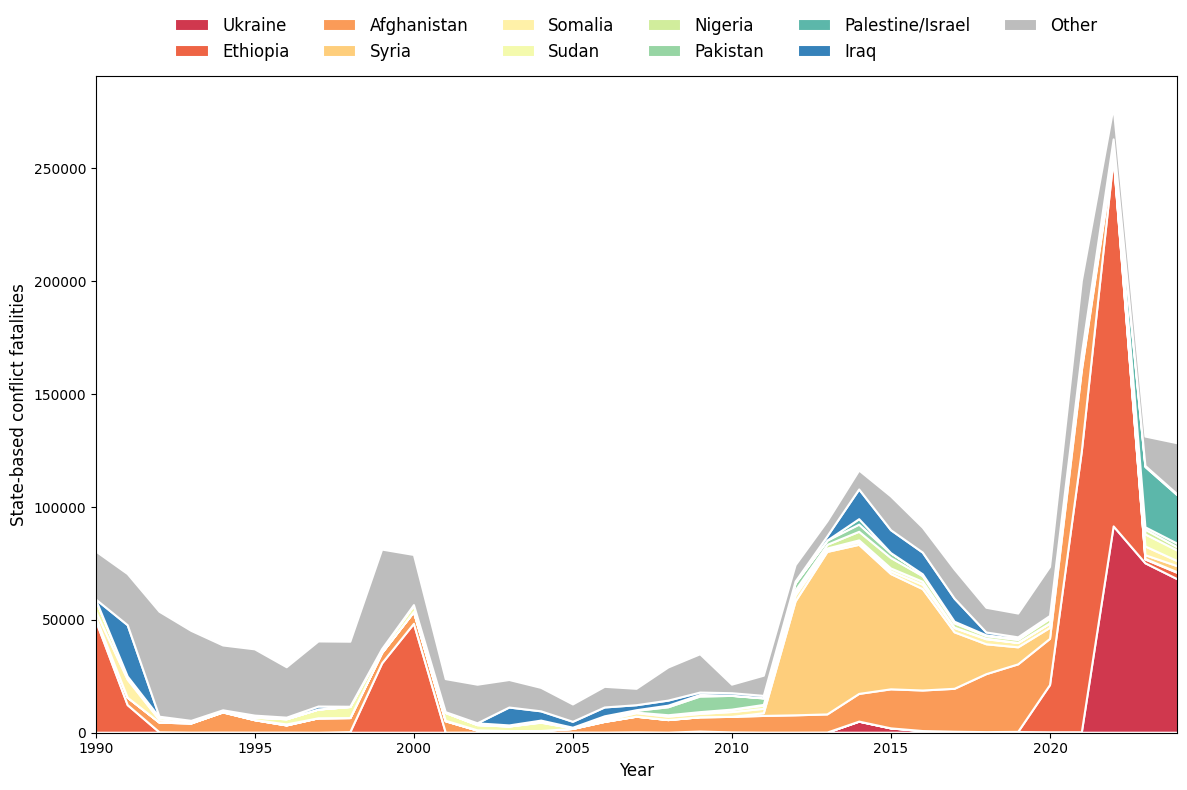

In [10]:
# aggregate data to yearly fatalities by country
df_stack = (
    data.groupby(["year", "country_name"])["ged_sb"]
      .sum()
      .unstack(fill_value=0)
)

# keep top 10 countries
top = df_stack.sum().nlargest(10).index

# add "Other" category
df_stack["Other"] = df_stack.drop(columns=top).sum(axis=1)
df_plot = df_stack[top.tolist() + ["Other"]]

# set color scheme
colors_main = sns.color_palette("Spectral", n_colors=len(df_plot.columns) - 1)
colors = list(colors_main) + ["#BDBDBD"]   # grey for Other

# set up figure
fig, ax = plt.subplots(figsize=(12,8))

# add label for Israel/palestine
labels = [
    "Palestine/Israel" if c == "Israel" else c
    for c in df_plot.columns
]

# create stackplot
stack = ax.stackplot(
    df_plot.index,
    df_plot.T.values,
    labels=labels,
    colors=colors,
    edgecolor="white",
    linewidth=1.5,
)

# plot metadata
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("State-based conflict fatalities", fontsize=12)
ax.set_xlim(1990, 2024)
ax.legend(
    stack,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    ncol=6,          
    frameon=False,
    fontsize=12
)

plt.tight_layout()
plt.savefig(f"{figure_path}figure_3.png", dpi=300)
plt.show()

#### Table 2: Descriptive statistics

In [11]:
metrics_table = (
    managers["Broad Model"]
    .get_disaggregated_metrics()
    .assign(
        test_period=lambda df: (
            df["test_start"]
            .map(lambda x: int(month_id_to_ym(x).split()[1]))
            .map(lambda y: f"{y}-{y+1}")
        )
    )
    .loc[lambda df: df["step"] == 12]
)

In [ ]:
summary_table = (
    metrics_table[metrics_table["distance"] > 0]
        .groupby("test_period")
        .agg(
            model_count=("train_start", "nunique"),
            distance_min=("distance", "min"),
            distance_max=("distance", "max")
        )
    .join(
        metrics_table[metrics_table["train_start"] == 144]
        .groupby("test_period")
        .agg(
            row_count=("test_period", "size"),
            sum=("ln_ged_sb_dep", lambda x: np.expm1(x).sum()),
            mean=("ln_ged_sb_dep", lambda x: np.expm1(x).mean()),
            std=("ln_ged_sb_dep", lambda x: np.expm1(x).std()),
            min=("ln_ged_sb_dep", lambda x: np.expm1(x).min()),
            max=("ln_ged_sb_dep", lambda x: np.expm1(x).max())
        )
    )
    .reset_index()
)

In [13]:
summary_table.to_csv(f"{table_path}table_2.csv", index=False)

### 2.2 Overall predictive performance

Set colormap for the plots

In [14]:
colormap = {
    "Broad Model": "peru",
    "Narrow Model": "grey",
    "WDI Model": "steelblue",
    "VDEM Model": "rebeccapurple",
    "Conflict History Model": "maroon",
}

#### Figure 4: Baseline MSLE by testing period

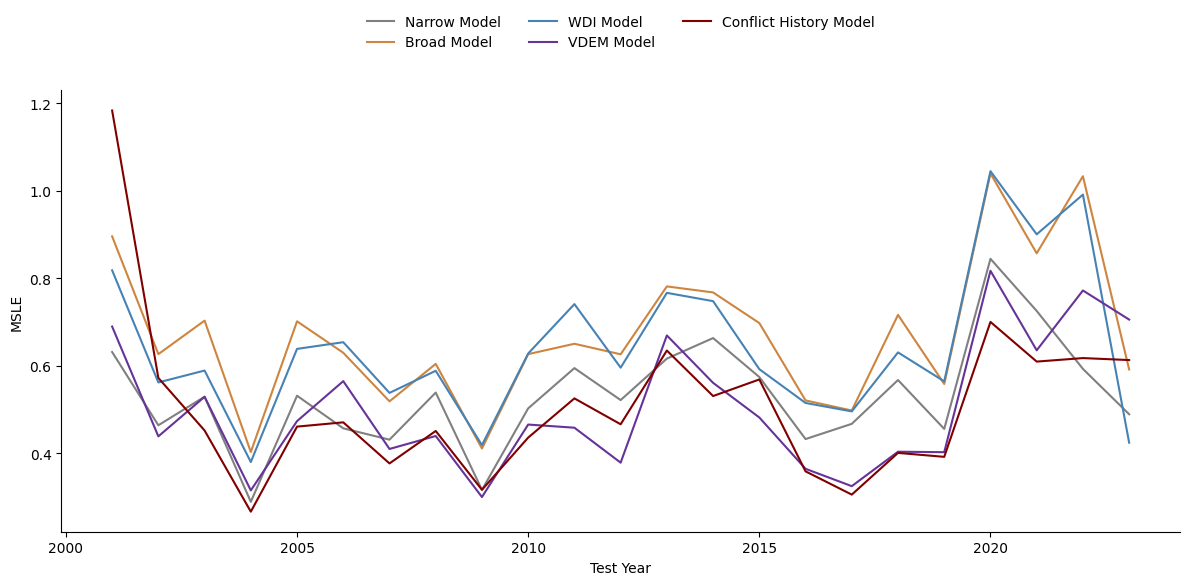

In [15]:
plt.figure(figsize=(12, 6))

for model in managers.keys():
    manager = managers[model]

    metrics = manager.get_disaggregated_metrics()
    metrics = metrics[metrics["step"] == step]

    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()
    grouped_positive = grouped[grouped["distance"] > 0]

    grouped_positive = grouped_positive[grouped_positive["distance"] == 6.5]

    grouped_positive["year"] = grouped_positive["test_start"].apply(lambda x: int(month_id_to_ym(x).split(" ")[1]))

    sns.lineplot(data=grouped_positive, x="year", 
                y="squared_log_error", legend=False, label = model, 
                color = colormap[model] if colormap is not None and model in colormap else None)

#plt.title(f"MSLE over Time of models at Step {step} for Distance Bin {6.5}")
plt.xlabel("Test Year")
plt.ylabel("MSLE")
plt.legend(
        loc="upper center",
        ncol=math.ceil(len(managers) / 2),
        bbox_to_anchor=(0.5, 1.20),
        frameon=False
    )
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_4.png", dpi=300)
plt.show()

### 2.3 Main results

#### Figure 5: MSLE by distance for all models

And then plot MSLE by distance for all models

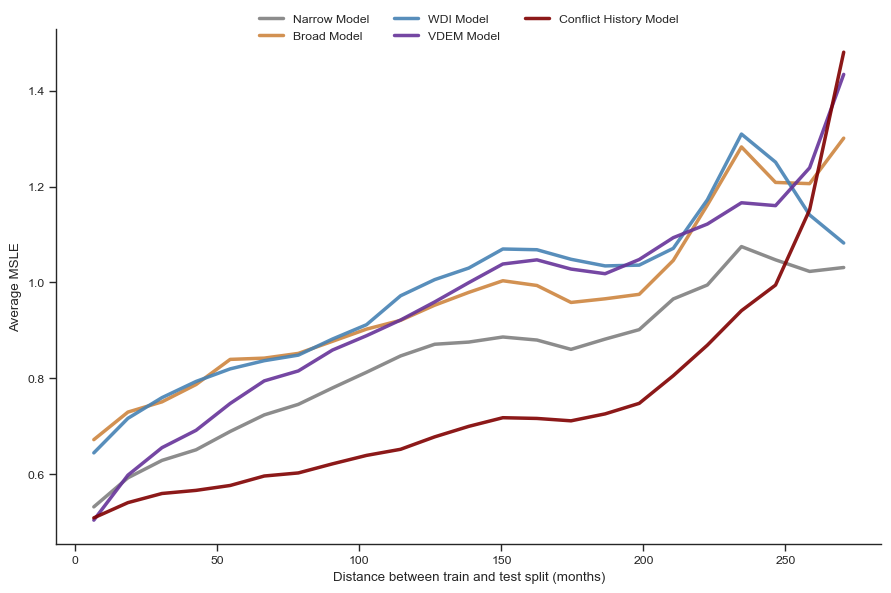

In [16]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

sns.set_palette("muted")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    # only plot for the future
    grouped = grouped[grouped["distance"] > 0]

    # plot mean mse and std of mse against distance
    sns.lineplot(
        data=grouped,
        x="distance",
        y="squared_log_error",   
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name]
        )
    
plt.xlabel("Distance between train and test split (months)")
plt.ylabel(f"Average MSLE")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
)
sns.despine()
plt.tight_layout()

plt.savefig(f"{figure_path}figure_5.png", dpi=300)
plt.show()

#### Figure 6: Skill score by distance between train and test period

First, create a function to calculate skill score:

In [17]:
def calculate_skill_score(
        metrics: pd.DataFrame, 
        baseline: str="test_start", 
        future: bool = True
    ) -> pd.DataFrame:
    """
    Calculate skill score for each test split compared to baseline model (closest train or test split).
    Skill Score = 1 - (model_error / baseline_error)

    Args:
        metrics: DataFrame containing columns [baseline], 'distance', metric 
        baseline: Whether to calculate skill score relative to "test_start" or "train_start"
        future: Whether to calculate skill score forwards or backwards in time. 
            Defaults to True, meaning skill score is calculated relative to closest train/test split in the future. 
            If False, skill score is calculated relative to closest train/test split in the past.
    """

    if baseline not in ["test_start", "train_start"]:
        raise ValueError(f"Invalid baseline: {baseline}. Options are 'test_start' or 'train_start'")

    if future:
        # calculate skill score relative to lowest positive distance
        idx = metrics.loc[metrics["distance"] > 0].groupby(baseline)["distance"].idxmin()
    else:
         # calculate skill score relative to highest negative distance
        idx = metrics.loc[metrics["distance"] < 0].groupby(baseline)["distance"].idxmax()

    # create lookup table
    baseline_error = metrics.loc[idx].set_index(baseline)["squared_log_error"]

    # map back to dataframe
    metrics[f"baseline_squared_log_error"] = metrics[baseline].map(baseline_error)

    # calculate skill score
    metrics[f"skill_score_squared_log_error"] = 1 - (metrics["squared_log_error"] / metrics[f"baseline_squared_log_error"])

    return metrics

And then calculate skill score for all models and plot:

In [18]:
group_by = "test_start"
step = 12
label = "MSLE"

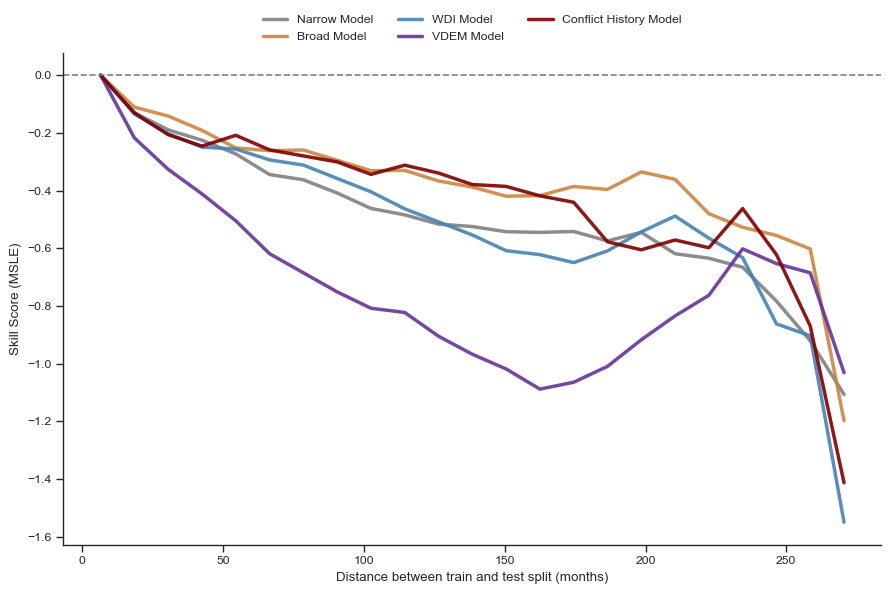

In [19]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_6.png", dpi = 300)
plt.show()

### 2.4 Extensions and Robustness

#### Figure 7: 

Excluding Ethiopia, Israel and Ukraine:

In [20]:
print(country_name_dict["Israel"])
print(country_name_dict["Ethiopia"])
print(country_name_dict["Ukraine"])

[218]
[57, 191]
[117]


And create a list of countries to filter out:

In [21]:
filter_list = [117, 57, 191, 218]

# only plot three models to avoid clutter:
managers_filt = {k: v for k, v in managers.items() if k in ["Broad Model", "Narrow Model", "Conflict History Model"]}

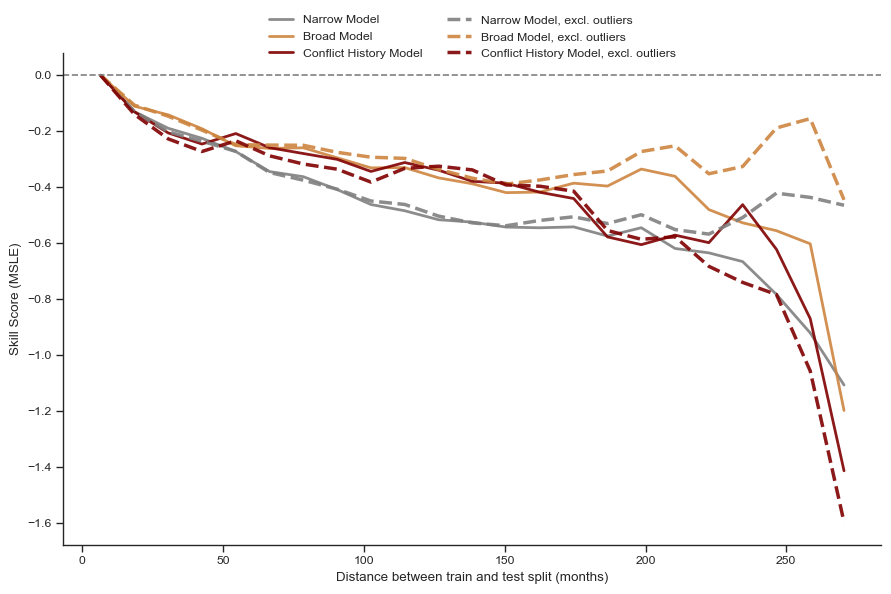

In [22]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers_filt.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error",    # separate lines by test_start
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )

# get metrics for each model and plot error over time
for model_name in managers_filt.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # filter out countries if specified (e.g., for robustness checks)
    metrics = metrics[~metrics["country_id"].isin(filter_list)]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}, excl. outliers",
        linewidth=2.5,
        linestyle="--",
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_7.png", dpi=300)
plt.show()

#### Figure 8: Skill score by backwards distance between train and test data

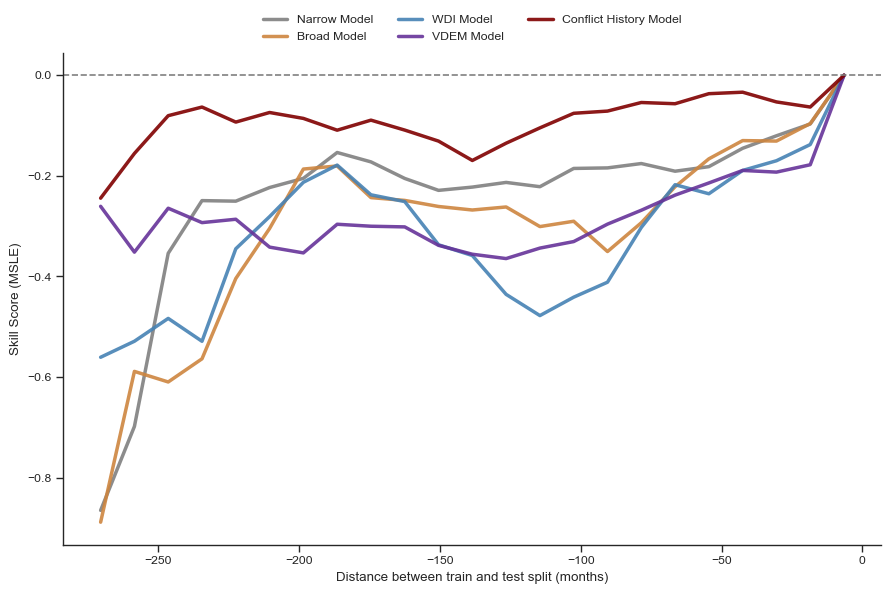

In [23]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, future=False) #type: ignore

    # only keep past predictions 
    skill_score = skill_score[skill_score["distance"] < 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_8.png", dpi=300)
plt.show()

## Appendices

### Appendix A: Skill score and MSLE plots for steps 3, 6, and 24

MSLE plots:

MSLE plot for step 3


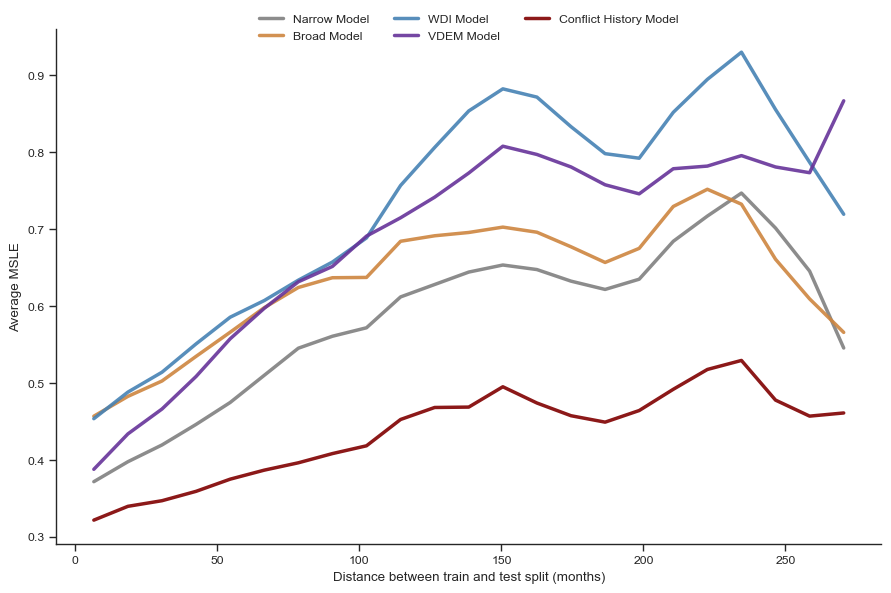

MSLE plot for step 6


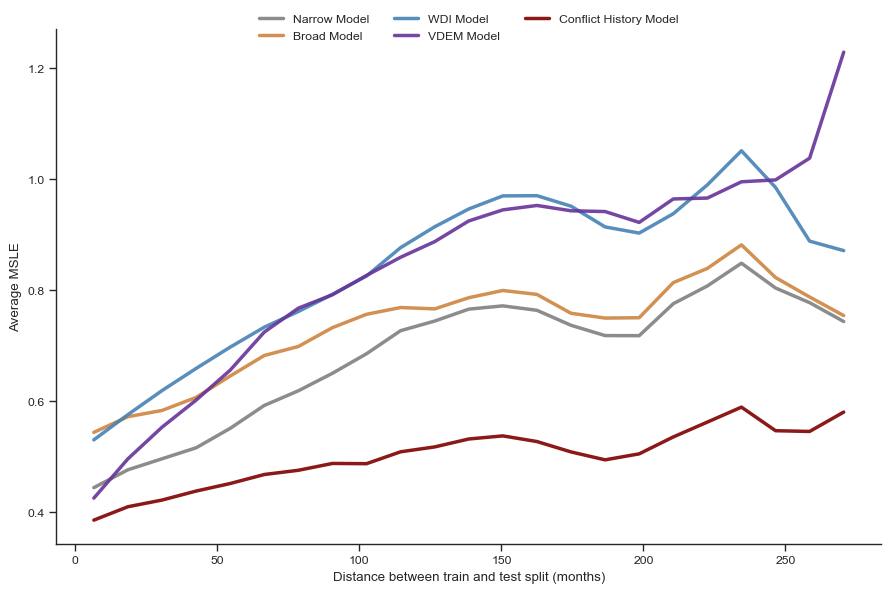

MSLE plot for step 24


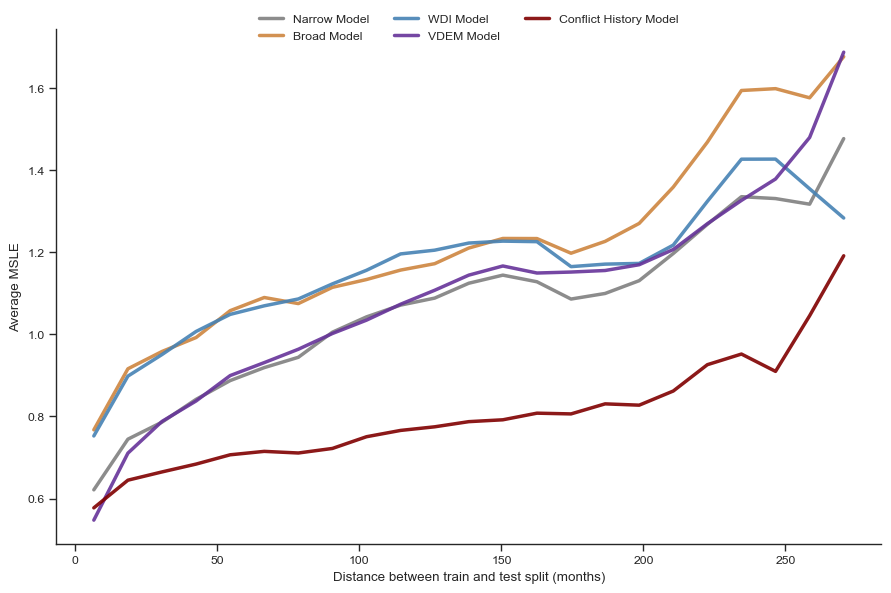

In [24]:
for step in [3, 6, 24]:

    print(f"MSLE plot for step {step}")

    plt.figure(figsize=(9, 6))
    sns.set_theme(style="ticks", context="paper")
    sns.set_palette("muted")

    # get metrics for each model and plot error over time
    for model_name in managers.keys():

        metrics = managers[model_name].get_disaggregated_metrics()

        # subset to specified step
        metrics = metrics[metrics["step"] == step]

        # calculate mean squared [log] error for each test_start, train_start combination
        grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

        # only plot for the future
        grouped = grouped[grouped["distance"] > 0]

        # plot mean mse and std of mse against distance
        sns.lineplot(
            data=grouped,
            x="distance",
            y="squared_log_error",   
            estimator="mean",
            errorbar=None,
            label= f"{model_name}",
            linewidth=2.5,
            alpha = 0.9,
            color = colormap[model_name]
            )
        
    plt.xlabel("Distance between train and test split (months)")
    plt.ylabel(f"Average MSLE")
    plt.legend(
        loc="upper center",
        ncol=math.ceil(len(managers) / 2),
        bbox_to_anchor=(0.5, 1.05),
        frameon=False,
    )
    sns.despine()
    plt.tight_layout()

    plt.savefig(f"{figure_path}appendix_a_msle_{step}.png", dpi=300)
    plt.show()

Skill score plots:

Skill Score plot for step 3


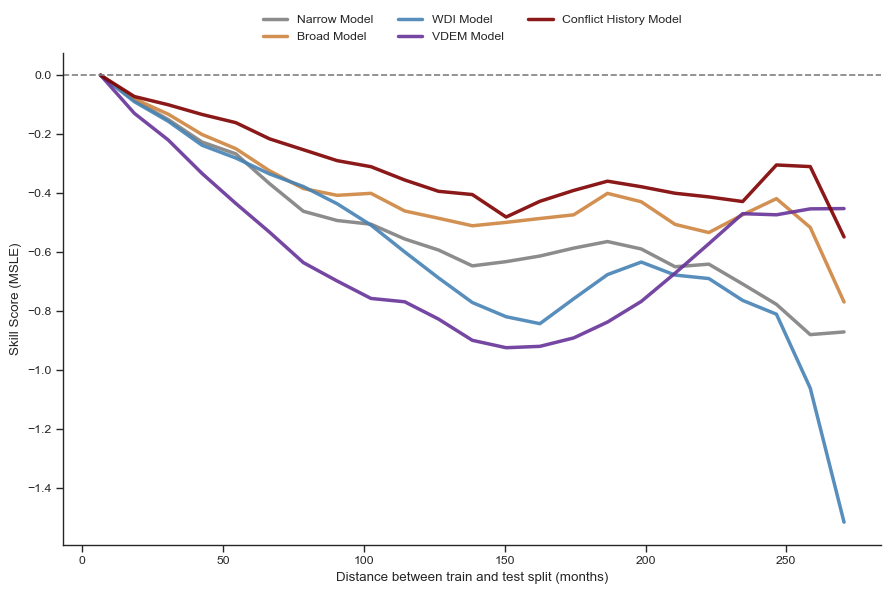

Skill Score plot for step 6


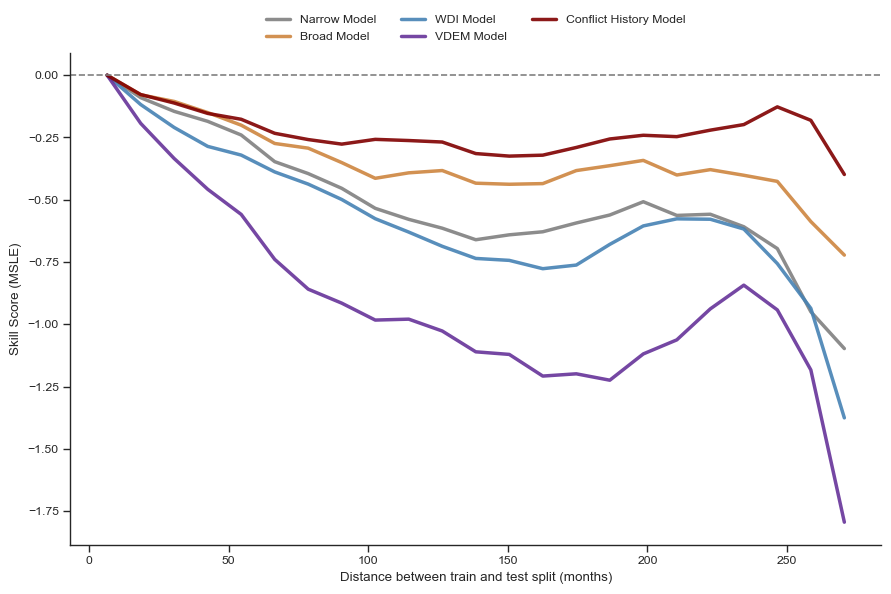

Skill Score plot for step 24


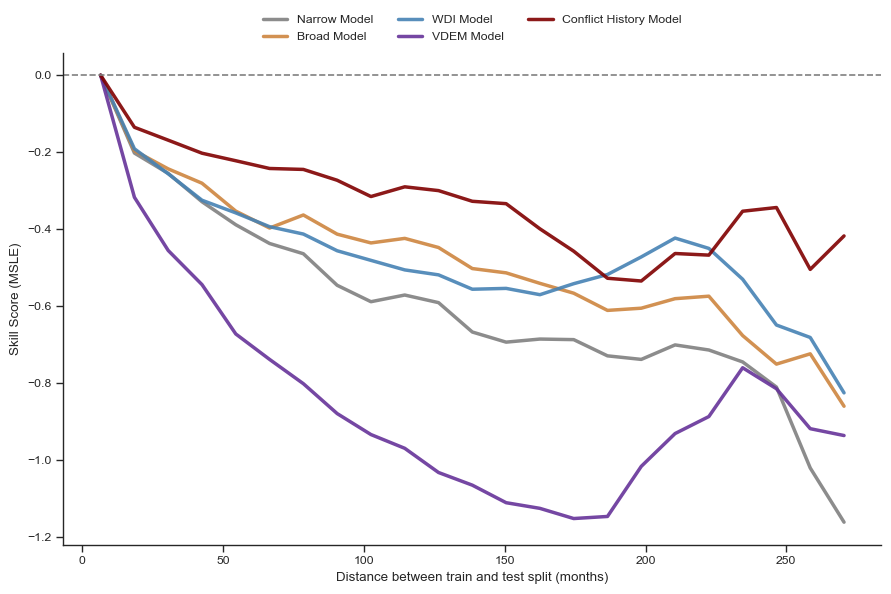

In [25]:
for step in [3, 6, 24]:

    print(f"Skill Score plot for step {step}")

    # set up plot
    plt.figure(figsize=(9, 6))
    sns.set_theme(style="ticks", context="paper")

    # get metrics for each model and plot error over time
    for model_name in managers.keys():

        metrics = managers[model_name].get_disaggregated_metrics()

        # subset to specified step
        metrics = metrics[metrics["step"] == step]

        # calculate mean squared [log] error for each test_start, train_start combination
        grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

        skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

        # only keep future predictions
        skill_score = skill_score[skill_score["distance"] > 0]

        sns.lineplot(
            data=skill_score,
            x="distance",
            y=f"skill_score_squared_log_error", 
            estimator="mean",
            errorbar=None,
            label= f"{model_name}",
            linewidth=2.5,
            alpha = 0.9,
            color = colormap[model_name] if colormap is not None and model_name in colormap else None
        )
        
    plt.xlabel("Distance between train and test split (months)")
    plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
    plt.ylabel(f"Skill Score ({label})")
    plt.legend(
        loc="upper center",
        ncol=math.ceil(len(managers) / 2),
        bbox_to_anchor=(0.5, 1.10),
        frameon=False
    )
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{figure_path}appendix_a_skill_score_{step}.png", dpi = 300)
    plt.show()

### Appendix B: MSLE by distance when predicting backwards

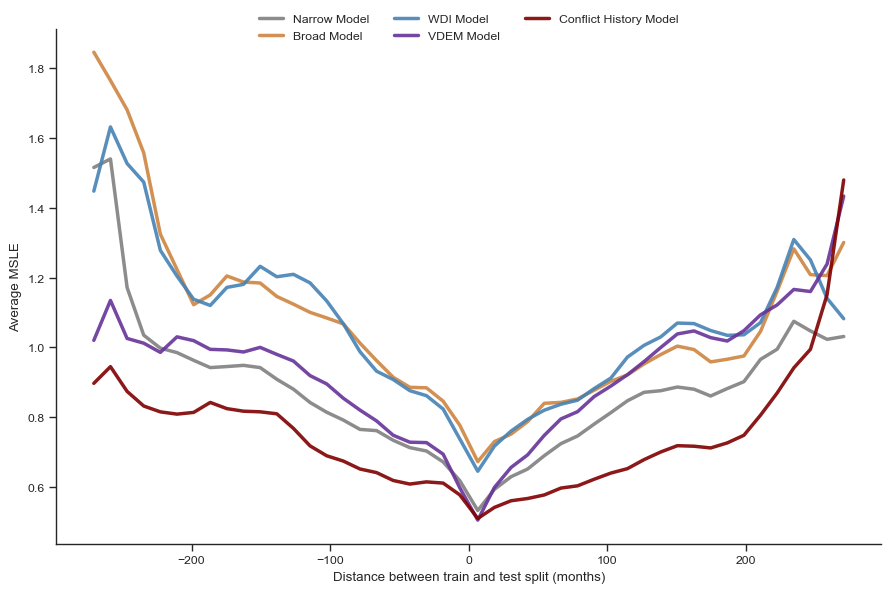

In [26]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

sns.set_palette("muted")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    # plot mean mse and std of mse against distance
    sns.lineplot(
        data=grouped,
        x="distance",
        y="squared_log_error",   
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name]
        )
    
plt.xlabel("Distance between train and test split (months)")
plt.ylabel(f"Average MSLE")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
)
sns.despine()
plt.tight_layout()

plt.savefig(f"{figure_path}appendix_b.png", dpi=300)
plt.show()

### Appendix C: Skill score plot, centering on training period

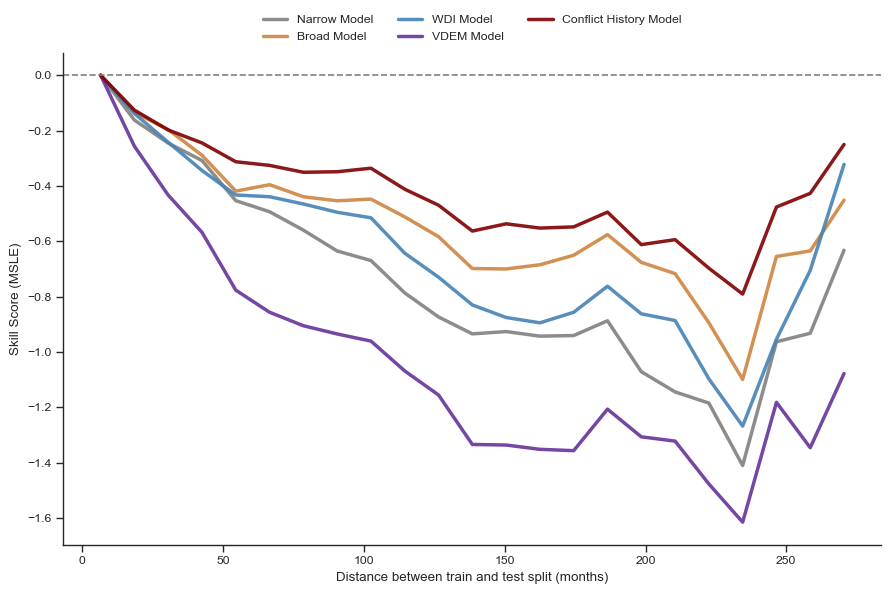

In [27]:
group_by = "train_start"

# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = managers[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}appendix_c.png", dpi = 300)
plt.show()

### Appendix D: Skill score plot with train period of 5 years, and 20 years

For this appendix, we first need to retrain the models with different training periods. We can then plot the skill score by distance for these different training periods.

#### Train window size of 5 years (60 months):

In [28]:
train_window_size = 60

In [29]:
managers_5_year: dict[str, DynamicModelManager] = {}

for model in model_list:
    print(f"Running model: {model.name}")

    model_data = pd.read_parquet(f"{views_data_path}{model.queryset}.parquet").reset_index()
    
    manager = DynamicModelManager(
        steps = [12],
        data = model_data,
        features = model.features,
        target = model.target,
        model_name= model.name,
        base_model = model.model,
        train_window_size = train_window_size,
        test_window_size = test_window_size,
        slide_window_size = slide_window_size,
        full_split = full_split,
        target_log_transformed=True
    )

    manager.fit()
    manager.predict()

    managers_5_year[model.name] = manager

Running model: Narrow Model


Fitting models: 100%|██████████| 30/30 [00:14<00:00,  2.07it/s]


Finished fitting all models in 14.53 seconds


Predicting: 100%|██████████| 870/870 [00:04<00:00, 207.23it/s]


Running model: Broad Model


...

Predicting: 100%|██████████| 870/870 [00:06<00:00, 140.25it/s]


Running model: Conflict History Model


Fitting models: 100%|██████████| 30/30 [00:12<00:00,  2.35it/s]


Finished fitting all models in 12.79 seconds


Predicting: 100%|██████████| 870/870 [00:04<00:00, 211.03it/s]


And then plot the skill score:

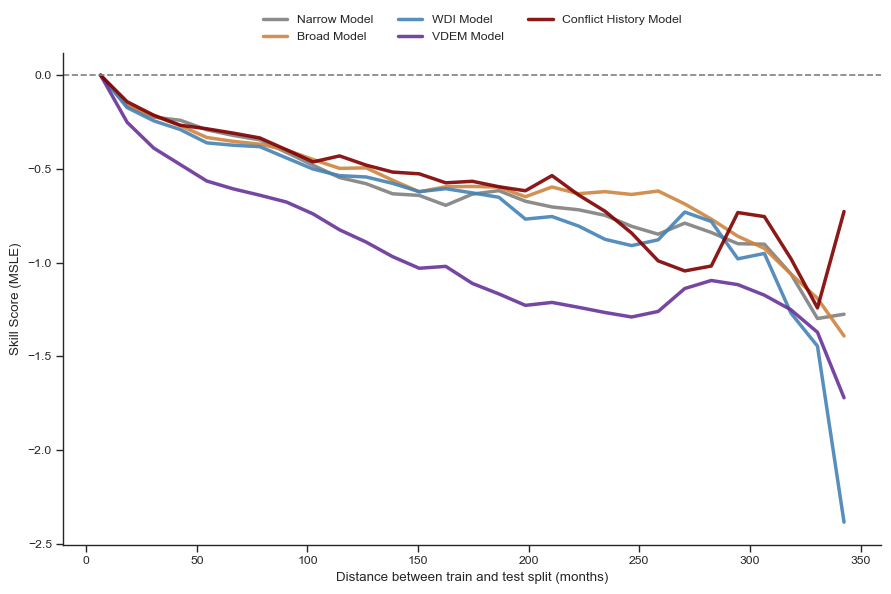

In [30]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

group_by = "test_start"

# get metrics for each model and plot error over time
for model_name in managers_5_year.keys():

    metrics = managers_5_year[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers_5_year) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}appendix_d_5_year.png", dpi = 300)
plt.show()

#### Train window size of 20 years (240 months):

In [31]:
train_window_size = 240

In [32]:
managers_20_year: dict[str, DynamicModelManager] = {}

for model in model_list:
    print(f"Running model: {model.name}")

    model_data = pd.read_parquet(f"{views_data_path}{model.queryset}.parquet").reset_index()
    
    manager = DynamicModelManager(
        steps = [12],
        data = model_data,
        features = model.features,
        target = model.target,
        model_name= model.name,
        base_model = model.model,
        train_window_size = train_window_size,
        test_window_size = test_window_size,
        slide_window_size = slide_window_size,
        full_split = full_split,
        target_log_transformed=True
    )

    manager.fit()
    manager.predict()

    managers_20_year[model.name] = manager

Running model: Narrow Model


Fitting models: 100%|██████████| 15/15 [00:09<00:00,  1.60it/s]


Finished fitting all models in 9.40 seconds


Predicting: 100%|██████████| 210/210 [00:00<00:00, 213.10it/s]


Running model: Broad Model


...

Predicting: 100%|██████████| 210/210 [00:01<00:00, 149.65it/s]


Running model: Conflict History Model


Fitting models: 100%|██████████| 15/15 [00:07<00:00,  1.96it/s]


Finished fitting all models in 7.64 seconds


Predicting: 100%|██████████| 210/210 [00:00<00:00, 215.96it/s]


And then plot skill score:

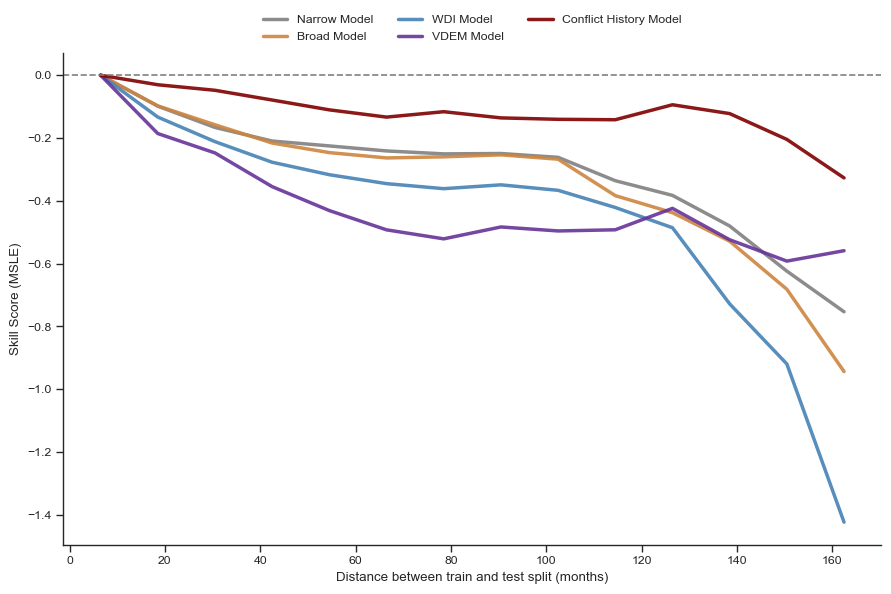

In [33]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers_20_year.keys():

    metrics = managers_20_year[model_name].get_disaggregated_metrics()

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_squared_log_error", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers_20_year) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}appendix_d_20_year.png", dpi = 300)
plt.show()

### Appendix E: Skill score plots with bootstrap confidence intervals

First, create a function to bootstrap the skill score:

In [34]:
def bootstrap_skill_score_by_country(
        metrics,
        n_bootstrap=1000,
        ci=0.9,
        group_by = "test_start",
        random_state=42
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    rng = np.random.default_rng(random_state)

    countries = metrics["country_id"].unique()
    n_countries = len(countries)

    bootstrap_results = []

    for b in tqdm.tqdm(range(n_bootstrap), desc="Bootstrapping skill scores:"):

        # 1. sample countries *with* replacement
        sampled_countries = rng.choice(
            countries,
            size=n_countries,
            replace=True
        )

        # 2. build bootstrap sample by concatenating data for sampled countries
        sampled_dfs = []
        for c in sampled_countries:
            sampled_dfs.append(
                metrics.loc[metrics["country_id"] == c]
            )
        boot_df = pd.concat(sampled_dfs, ignore_index=True)

        # 3. calculate skill score on bootstrap sample
        aggregated = boot_df.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()
        skill_score = calculate_skill_score(aggregated, baseline=group_by)

        skill_score["bootstrap_iter"] = b

        # 4. subset to future predictions
        skill_score = skill_score[skill_score["distance"] > 0]

        bootstrap_results.append(skill_score)

    # 5.combine all bootstrap iterations
    bootstrap_results = pd.concat(bootstrap_results, ignore_index=True)

    # 6. compute confidence intervals
    alpha = 1 - ci
    summary = (
        bootstrap_results
        .groupby("distance")["skill_score_squared_log_error"]
        .agg(
            mean="mean",
            lower=lambda x: np.quantile(x, alpha / 2),
            upper=lambda x: np.quantile(x, 1 - alpha / 2),
        )
        .reset_index()
    )

    return summary, bootstrap_results

And then bootstrap the skill score by distance for each model

In [35]:
step = 12
n_bootstrap = 1000
ci = 0.95

In [36]:
bootstrap_results_all = {}

for model in managers.keys():

    print(f"Bootstrapping skill scores for model: {model}")

    manager = managers[model]
    metrics = manager.get_disaggregated_metrics()

    # subset to specified step
    metrics_filt = metrics[metrics["step"] == step]

    summary, boot = bootstrap_skill_score_by_country(metrics_filt, n_bootstrap = n_bootstrap, ci = ci)

    bootstrap_results_all[model] = {
        "summary": summary,
        "bootstrap_results": boot
    }

Bootstrapping skill scores for model: Narrow Model


Bootstrapping skill scores:: 100%|██████████| 1000/1000 [03:22<00:00,  4.94it/s]


Bootstrapping skill scores for model: Broad Model


Bootstrapping skill scores:: 100%|██████████| 1000/1000 [02:38<00:00,  6.31it/s]


Bootstrapping skill scores for model: WDI Model


Bootstrapping skill scores:: 100%|██████████| 1000/1000 [02:33<00:00,  6.51it/s]


Bootstrapping skill scores for model: VDEM Model


Bootstrapping skill scores:: 100%|██████████| 1000/1000 [04:08<00:00,  4.03it/s]


Bootstrapping skill scores for model: Conflict History Model


Bootstrapping skill scores:: 100%|██████████| 1000/1000 [04:47<00:00,  3.48it/s]


And finally plot the skill score with confidence intervals for each model:

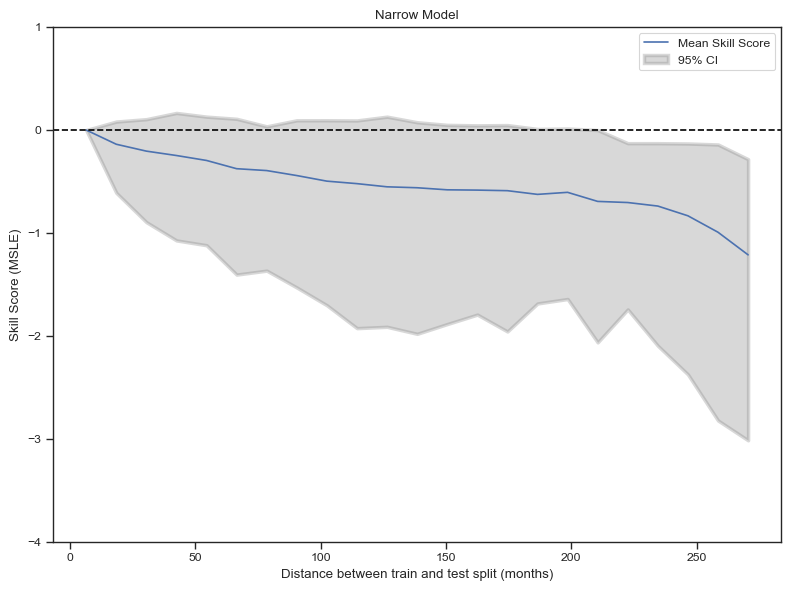

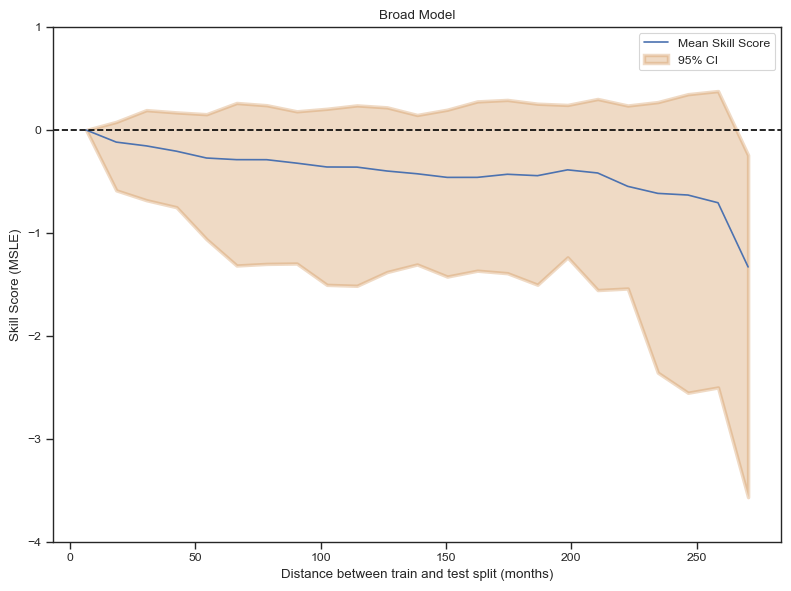

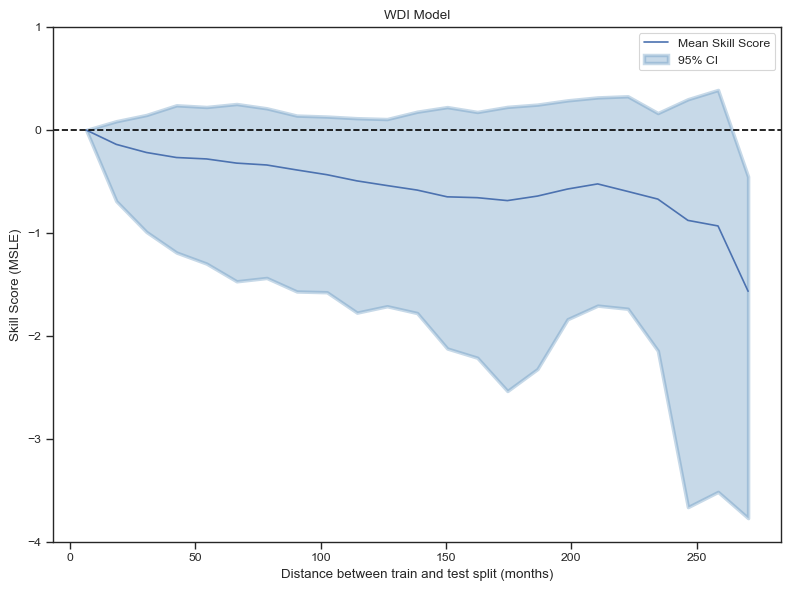

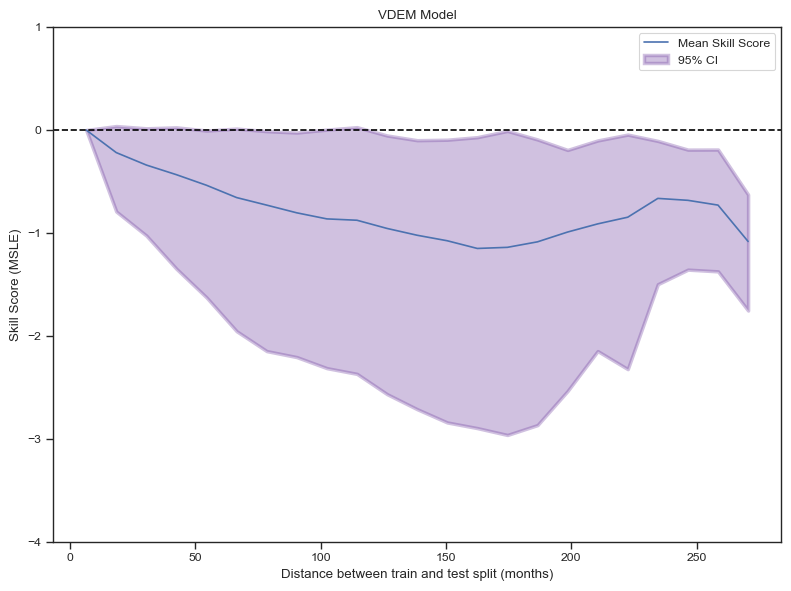

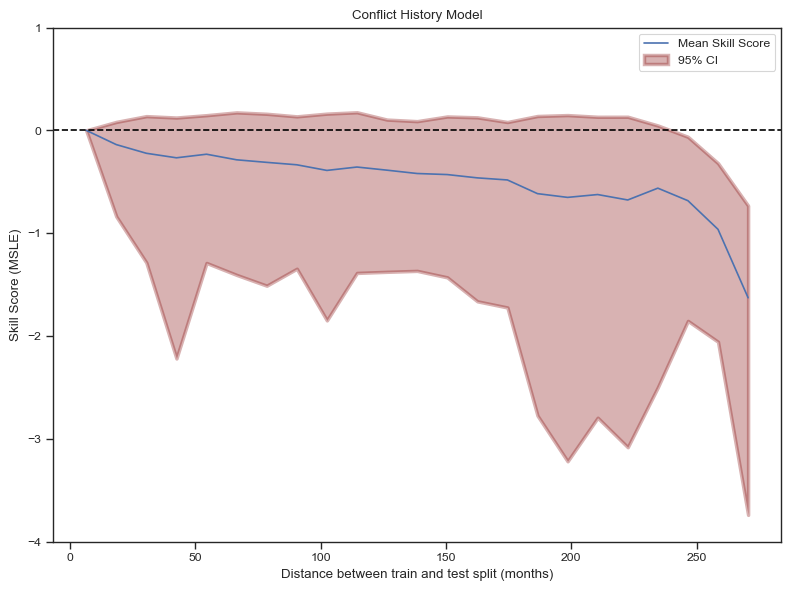

In [37]:
for model_name in managers.keys():

    summary = bootstrap_results_all[model_name]["summary"]

    # Sort for clean plotting
    summary = summary.sort_values("distance")

    fig, ax = plt.subplots(figsize=(8, 6))

    # Mean line
    ax.plot(
        summary["distance"],
        summary["mean"],
        label="Mean Skill Score"
    )

    # Confidence interval band
    ax.fill_between(
        summary["distance"],
        summary["lower"],
        summary["upper"],
        alpha=0.3,
        label="95% CI",
        linewidth=2.5,
        color = colormap[model_name]
    )

    # add horizontal line at y=0
    ax.axhline(0, linestyle="--", color="black", linewidth=1.2)  # baseline reference

    ax.set_xlabel("Distance between train and test split (months)")
    ax.set_ylabel("Skill Score (MSLE)")
    ax.set_title(f"{model_name}")
    ax.set_ylim(-4, 1)

    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{figure_path}appendix_e_bootstrap_{model_name.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()